# Build a supervised model for predicting Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc with a defined applicability domain. It should be able to predict logKoc from a SMILES input and tell the user whether the new molecules fall into its AD. 

#### Tasks:
1) Load the training data
2) Build a supervised model of your choice (e.g., MACCS keys x Random Forest, but feel free to go for something more fancy) on 80% of the training data
3) Use an AD metric of your choice
4) Evaluate model on a 20% test set, and compare the prediction error with your AD metric
5) Predict the Koc and AD for 3 new substances.

In [1]:
# import
from rdkit import Chem
import pandas as pd


#### 1. Load training data and split into train/test 80/20

In [2]:
# Loading the data from an sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC']}
    }
    for m in supplier if m is not None
])

In [3]:
df.head()

,SMILES,preferred_name,LogKOC
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9


#### 2. Build a supervised model of your choice

Maccs Keys + Random Forest

In [4]:
from utils import maccs_fp_from_smiles # import function from utils

smiles = df['SMILES'].values # Structures (SMILES)
y = df["LogKOC"].values.astype(float) # Target variable

X, idx = maccs_fp_from_smiles(smiles) # Calculate fingerprints (MACCS)
y = y[idx] # idx: indexes where descriptors could be calculated 

# Verify for how many compounds features could be calculated
print(f'Input feature calculation: {len(smiles)} SMILES\n \
    --> Features calculated for {len(idx)} molecules')

# create dataframe
all_df = pd.DataFrame({'SMILES': df['SMILES'][idx], 
                           'LogKOC': df['LogKOC'][idx],
                           })

Input feature calculation: 728 SMILES
     --> Features calculated for 728 molecules


In [5]:
all_df.head()

,SMILES,LogKOC
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,5.31
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,5.95
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,3.35
3,COc1ccc(NC(C)=O)cc1,1.4
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,1.9


In [6]:
# split data into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 582, Test: 146


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

#### 3. Choose an AD metric and define an AD threshold

Average of kernel densities by set: 
Train: -4.503986943587691 
Test:  -4.461708905905512
Test within AD:  140/146
Test outside AD: 6/146


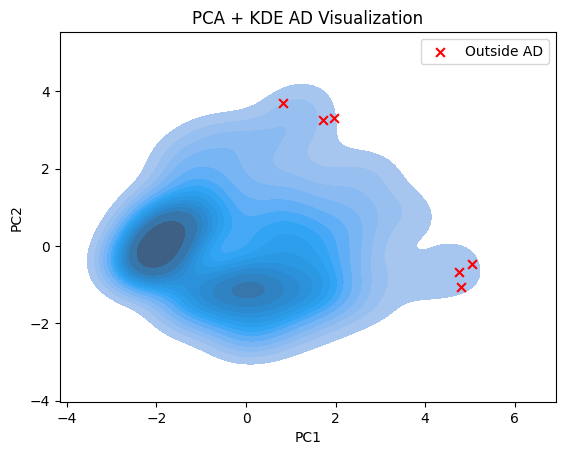

In [17]:
# KDE works better with continuous variables,
# so we calculate density on the 3 principal components
pc_list = ['PC1', 'PC2', 'PC3']

# ← CHANGE 1: fit PCA on X_train, transform X_test
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# ← CHANGE 2: create DataFrames from your arrays
train_df = pd.DataFrame(X_train_pca, columns=pc_list)
test_df  = pd.DataFrame(X_test_pca,  columns=pc_list)

pca_X_train = train_df[pc_list]
pca_X_test  = test_df[pc_list]

kde = KernelDensity(kernel="gaussian", bandwidth=1.0)
scaler = StandardScaler()
pca_X_train_standard = scaler.fit_transform(pca_X_train)
kde.fit(pca_X_train_standard)

# test data
pca_X_test_standard = scaler.transform(pca_X_test)
kernel_density_train = kde.score_samples(pca_X_train_standard)
kernel_density_test  = kde.score_samples(pca_X_test_standard)

train_df['Kernel_Density'] = kernel_density_train
test_df['Kernel_Density']  = kernel_density_test

print(f'Average of kernel densities by set: \n'
      f'Train: {kernel_density_train.mean()} \n'
      f'Test:  {kernel_density_test.mean()}')

# ← CHANGE 3: AD threshold from training density
threshold = np.percentile(kernel_density_train, 5)
in_ad  = kernel_density_test >= threshold
out_ad = ~in_ad
print(f"Test within AD:  {in_ad.sum()}/{len(in_ad)}")
print(f"Test outside AD: {out_ad.sum()}/{len(in_ad)}")

# Visualize kernel density of the training space in 2D
kde_train_data = train_df[['PC1', 'PC2']]
sns.kdeplot(kde_train_data, x='PC1', y='PC2', fill=True, levels=15)
plt.scatter(test_df.loc[out_ad, 'PC1'], test_df.loc[out_ad, 'PC2'],
            marker='x', color='red', alpha=1, s=40, label='Outside AD')
plt.legend()
plt.title("PCA + KDE AD Visualization")
plt.show()

#### 4) Evaluate model (R2, RMSE) on test set and compare the prediction error with your AD metric

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

# Metrics on full test set
r2_test   = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Metrics split by AD status
r2_in     = r2_score(y_test[in_ad],  y_pred_test[in_ad])
rmse_in   = np.sqrt(mean_squared_error(y_test[in_ad],  y_pred_test[in_ad]))

r2_out    = r2_score(y_test[out_ad], y_pred_test[out_ad])
rmse_out  = np.sqrt(mean_squared_error(y_test[out_ad], y_pred_test[out_ad]))

print(f"{'':20} {'R²':>6} {'RMSE':>6}")
print(f"{'All test':20} {r2_test:>6.3f} {rmse_test:>6.3f}")
print(f"{'Within AD':20} {r2_in:>6.3f} {rmse_in:>6.3f}")
print(f"{'Outside AD':20} {r2_out:>6.3f} {rmse_out:>6.3f}")

                         R²   RMSE
All test              0.634  0.719
Within AD             0.634  0.727
Outside AD            0.270  0.498


#### 5) Predict the Koc and AD for 3 new substances. 

In [8]:
smiles = {'PFOA': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O', 
          'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
          'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'} # or choose your own! 

             Predicted logKoc  Predicted Koc  KDE log-density  Within AD
PFOA                 0.299474       1.992849        -4.053187       True
Bisphenol A          2.997953     995.298463        -4.193577       True
Caffeine             2.306780     202.665582        -4.590058       True


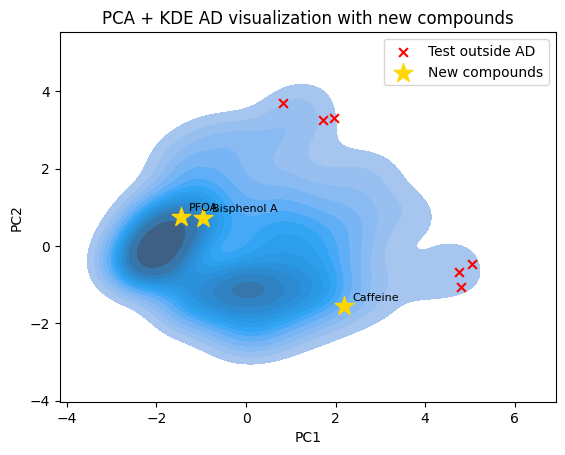

In [18]:
#### 5) Predict the Koc and AD for 3 new substances.
new_smiles = {'PFOA': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O', 
              'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
              'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'}

# Step 1: MACCS fingerprints for new compounds
X_new, idx_new = maccs_fp_from_smiles(np.array(list(new_smiles.values())))
names_new = np.array(list(new_smiles.keys()))[idx_new]

# Step 2: predict logKoc
y_pred_new = rf.predict(X_new)

# Step 3: PCA + scale using the ALREADY FITTED pca and scaler
X_new_pca        = pca.transform(X_new)
new_df           = pd.DataFrame(X_new_pca, columns=pc_list, index=names_new)
X_new_standard   = scaler.transform(new_df[pc_list])

# Step 4: KDE density and AD flag
kernel_density_new = kde.score_samples(X_new_standard)
in_ad_new  = kernel_density_new >= threshold

# Step 5: results table
results = pd.DataFrame({
    'Predicted logKoc': y_pred_new,
    'Predicted Koc':    10**y_pred_new,
    'KDE log-density':  kernel_density_new,
    'Within AD':        in_ad_new
}, index=names_new)

print(results)

# Step 6: plot new compounds on the KDE map
sns.kdeplot(kde_train_data, x='PC1', y='PC2', fill=True, levels=15)
plt.scatter(test_df.loc[out_ad, 'PC1'], test_df.loc[out_ad, 'PC2'],
            marker='x', color='red', s=40, label='Test outside AD')
plt.scatter(new_df['PC1'], new_df['PC2'],
            marker='*', color='gold', s=200, label='New compounds')
for name, row in new_df.iterrows():
    plt.annotate(name, (row['PC1'], row['PC2']), 
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.legend()
plt.title("PCA + KDE AD visualization with new compounds")
plt.show()

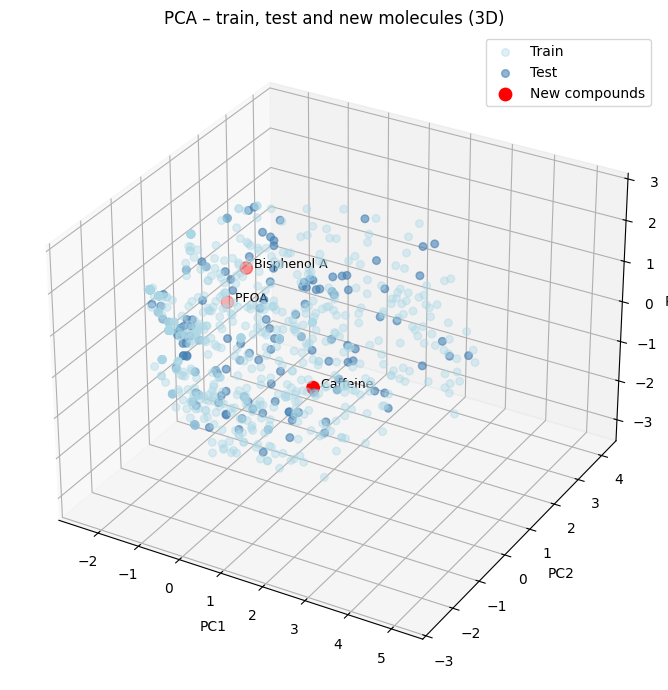

In [22]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Training set
ax.scatter(train_df['PC1'], train_df['PC2'], train_df['PC3'],
           c='lightblue', alpha=0.4, s=30, label='Train')

# Test set
ax.scatter(test_df['PC1'], test_df['PC2'], test_df['PC3'],
           c='steelblue', alpha=0.6, s=30, label='Test')

# New compounds
ax.scatter(new_df['PC1'], new_df['PC2'], new_df['PC3'],
           c='red', s=80, zorder=5, label='New compounds')
for name, row in new_df.iterrows():
    ax.text(row['PC1'], row['PC2'], row['PC3'], f'  {name}', fontsize=9)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("PCA – train, test and new molecules (3D)")
ax.legend()
plt.tight_layout()
plt.show()

### Questions:
- Which AD metric did you choose, and why?
- PCA + KDE: compress those 167 binary MACCS bits into 3 main features, then draw a density boundary around the training data. If a point falls below the 5th percentile density, it’s outside.
- How well does your model perform? Can you trust your AD metric?
- No. Within‑AD R² (0.634) equals the overall test set, but RMSE is actually higher (0.727 vs 0.719), while outside AD has lower RMSE (0.498). AD fails to separate good from bad predictions, therefore not trustworthy.
- Are the new substances within the AD? Can you trust the Koc predictions? 
- All three are inside per the threshold, but:
- Bisphenol A: most reliable.
- Caffeine: low density, least confident.
- PFOA: flagged inside but chemically suspicious because of Flourinated compound, prediction likely wrong.
